#  

----
# <center><font color="#615FFF" size="8"> Hackathon Oracle </font></center>
----

#  

----
# <center><font color="#615FFF" size="6">1. Carga Datos </font></center>
----

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_excel("/content/data.xlsx")

In [3]:
data.shape

(7043, 21)

In [4]:
data.sample(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
5872,4550-EVXNY,Female,0,No,Yes,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,69.65,69.65,Yes
4474,1139-WUOAH,Male,0,No,No,57,No,No phone service,DSL,No,...,Yes,Yes,Yes,Yes,Two year,No,Credit card (automatic),53.35,3090.05,No
971,5002-GCQFH,Male,0,Yes,No,49,Yes,Yes,Fiber optic,Yes,...,No,No,Yes,No,Month-to-month,Yes,Bank transfer (automatic),93.85,4733.10,No
1289,9968-FFVVH,Male,0,No,No,63,Yes,Yes,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),68.80,4111.35,No
927,9625-QSTYE,Female,0,No,No,13,Yes,No,Fiber optic,No,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,81.15,952.30,Yes


In [5]:
data.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [6]:
data.rename(columns={
    'customerID': 'id_cliente',
    'gender': 'genero',
    'SeniorCitizen': 'adulto_mayor',
    'Partner': 'tiene_pareja',
    'Dependents': 'tiene_dependientes',
    'tenure': 'antiguedad_meses',
    'PhoneService': 'servicio_telefono',
    'MultipleLines': 'lineas_multiples',
    'InternetService': 'servicio_internet',
    'OnlineSecurity': 'seguridad_en_linea',
    'OnlineBackup': 'respaldo_en_linea',
    'DeviceProtection': 'proteccion_dispositivo',
    'TechSupport': 'soporte_tecnico',
    'StreamingTV': 'streaming_tv',
    'StreamingMovies': 'streaming_peliculas',
    'Contract': 'tipo_contrato',
    'PaperlessBilling': 'facturacion_electronica',
    'PaymentMethod': 'metodo_pago',
    'MonthlyCharges': 'cargo_mensual',
    'TotalCharges': 'cargos_totales',
    'Churn': 'abandono_cliente'
}, inplace=True)


In [7]:
data.sample(5)

,id_cliente,genero,adulto_mayor,tiene_pareja,tiene_dependientes,antiguedad_meses,servicio_telefono,lineas_multiples,servicio_internet,seguridad_en_linea,...,proteccion_dispositivo,soporte_tecnico,streaming_tv,streaming_peliculas,tipo_contrato,facturacion_electronica,metodo_pago,cargo_mensual,cargos_totales,abandono_cliente
3584,9552-TGUZV,Male,0,Yes,No,8,Yes,No,Fiber optic,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,75.00,658.10,No
2086,2955-BJZHG,Male,0,Yes,Yes,17,Yes,No,Fiber optic,No,...,No,No,Yes,No,Month-to-month,No,Electronic check,80.85,1400.85,Yes
2357,9251-WNSOD,Female,0,Yes,No,67,Yes,Yes,DSL,Yes,...,Yes,No,No,Yes,One year,No,Mailed check,75.10,5064.45,No
6297,0864-FVJNJ,Female,0,Yes,Yes,64,Yes,Yes,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,One year,No,Electronic check,113.35,7222.75,No
3254,3629-ZNKXA,Male,1,No,No,17,Yes,No,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,101.80,1752.45,No


In [8]:
# memoria de datos

round(data.memory_usage(deep=True).sum() / 1024**2, 3)

np.float64(6.506)

In [9]:
data.isnull().sum()

,0
id_cliente,0
genero,0
adulto_mayor,0
tiene_pareja,0
tiene_dependientes,0
antiguedad_meses,0
servicio_telefono,0
lineas_multiples,0
servicio_internet,0
seguridad_en_linea,0


#  

----
# <center><font color="#615FFF" size="6">2. Analisis Univariado </font></center>
----

In [10]:
cat_cols = data.select_dtypes(include="object").columns
num_cols = data.select_dtypes(exclude="object").columns

In [11]:
data[num_cols].describe()

,adulto_mayor,antiguedad_meses,cargo_mensual,cargos_totales
count,7043.000000,7043.000000,7043.000000,7032.000000
mean,0.162147,32.371149,64.761692,2283.300441
std,0.368612,24.559481,30.090047,2266.771362
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3794.737500
max,1.000000,72.000000,118.750000,8684.800000



# <center><font color="#073E9C" size="5">Distribución de variables numérica </font></center>

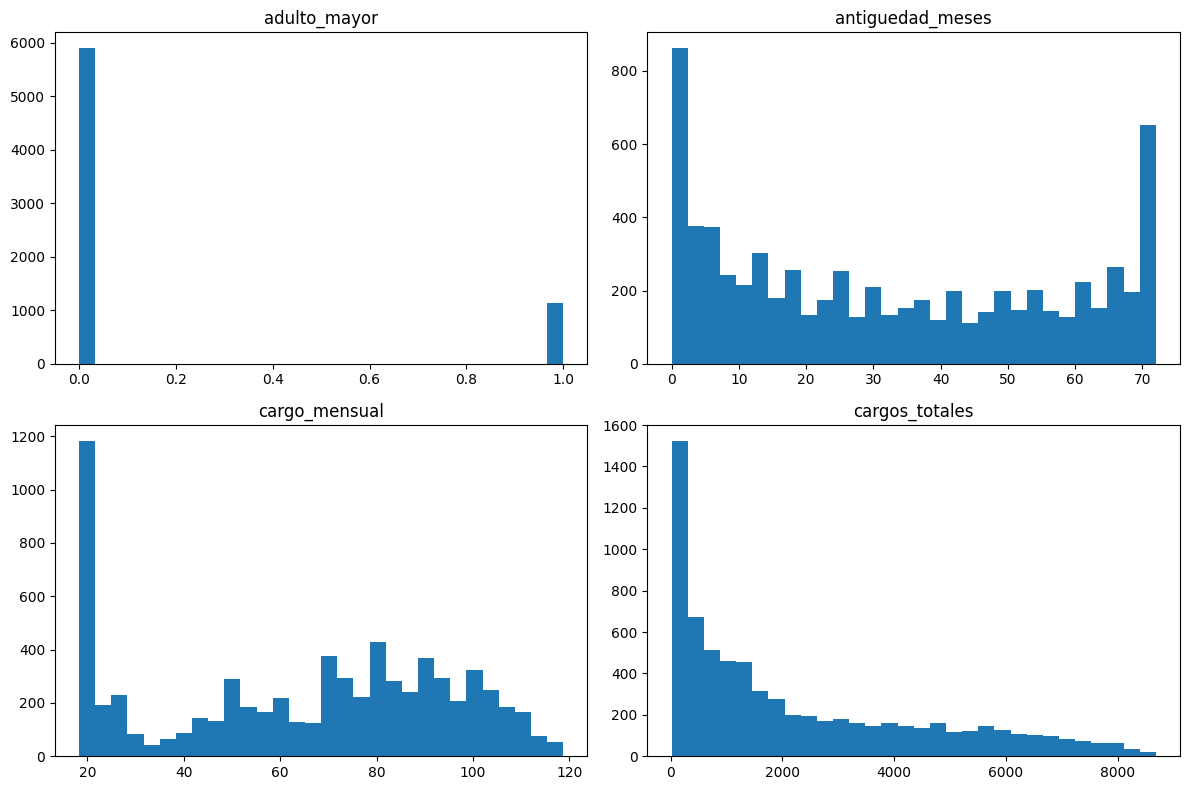

In [12]:
import math

n_cols = 2
n_rows = math.ceil(len(num_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(data[col], bins=30)
    axes[i].set_title(col)

# Eliminar ejes vacíos
for j in range(len(num_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


# <center><font color="#073E9C" size="5">Distribución de variables categóricas </font></center>

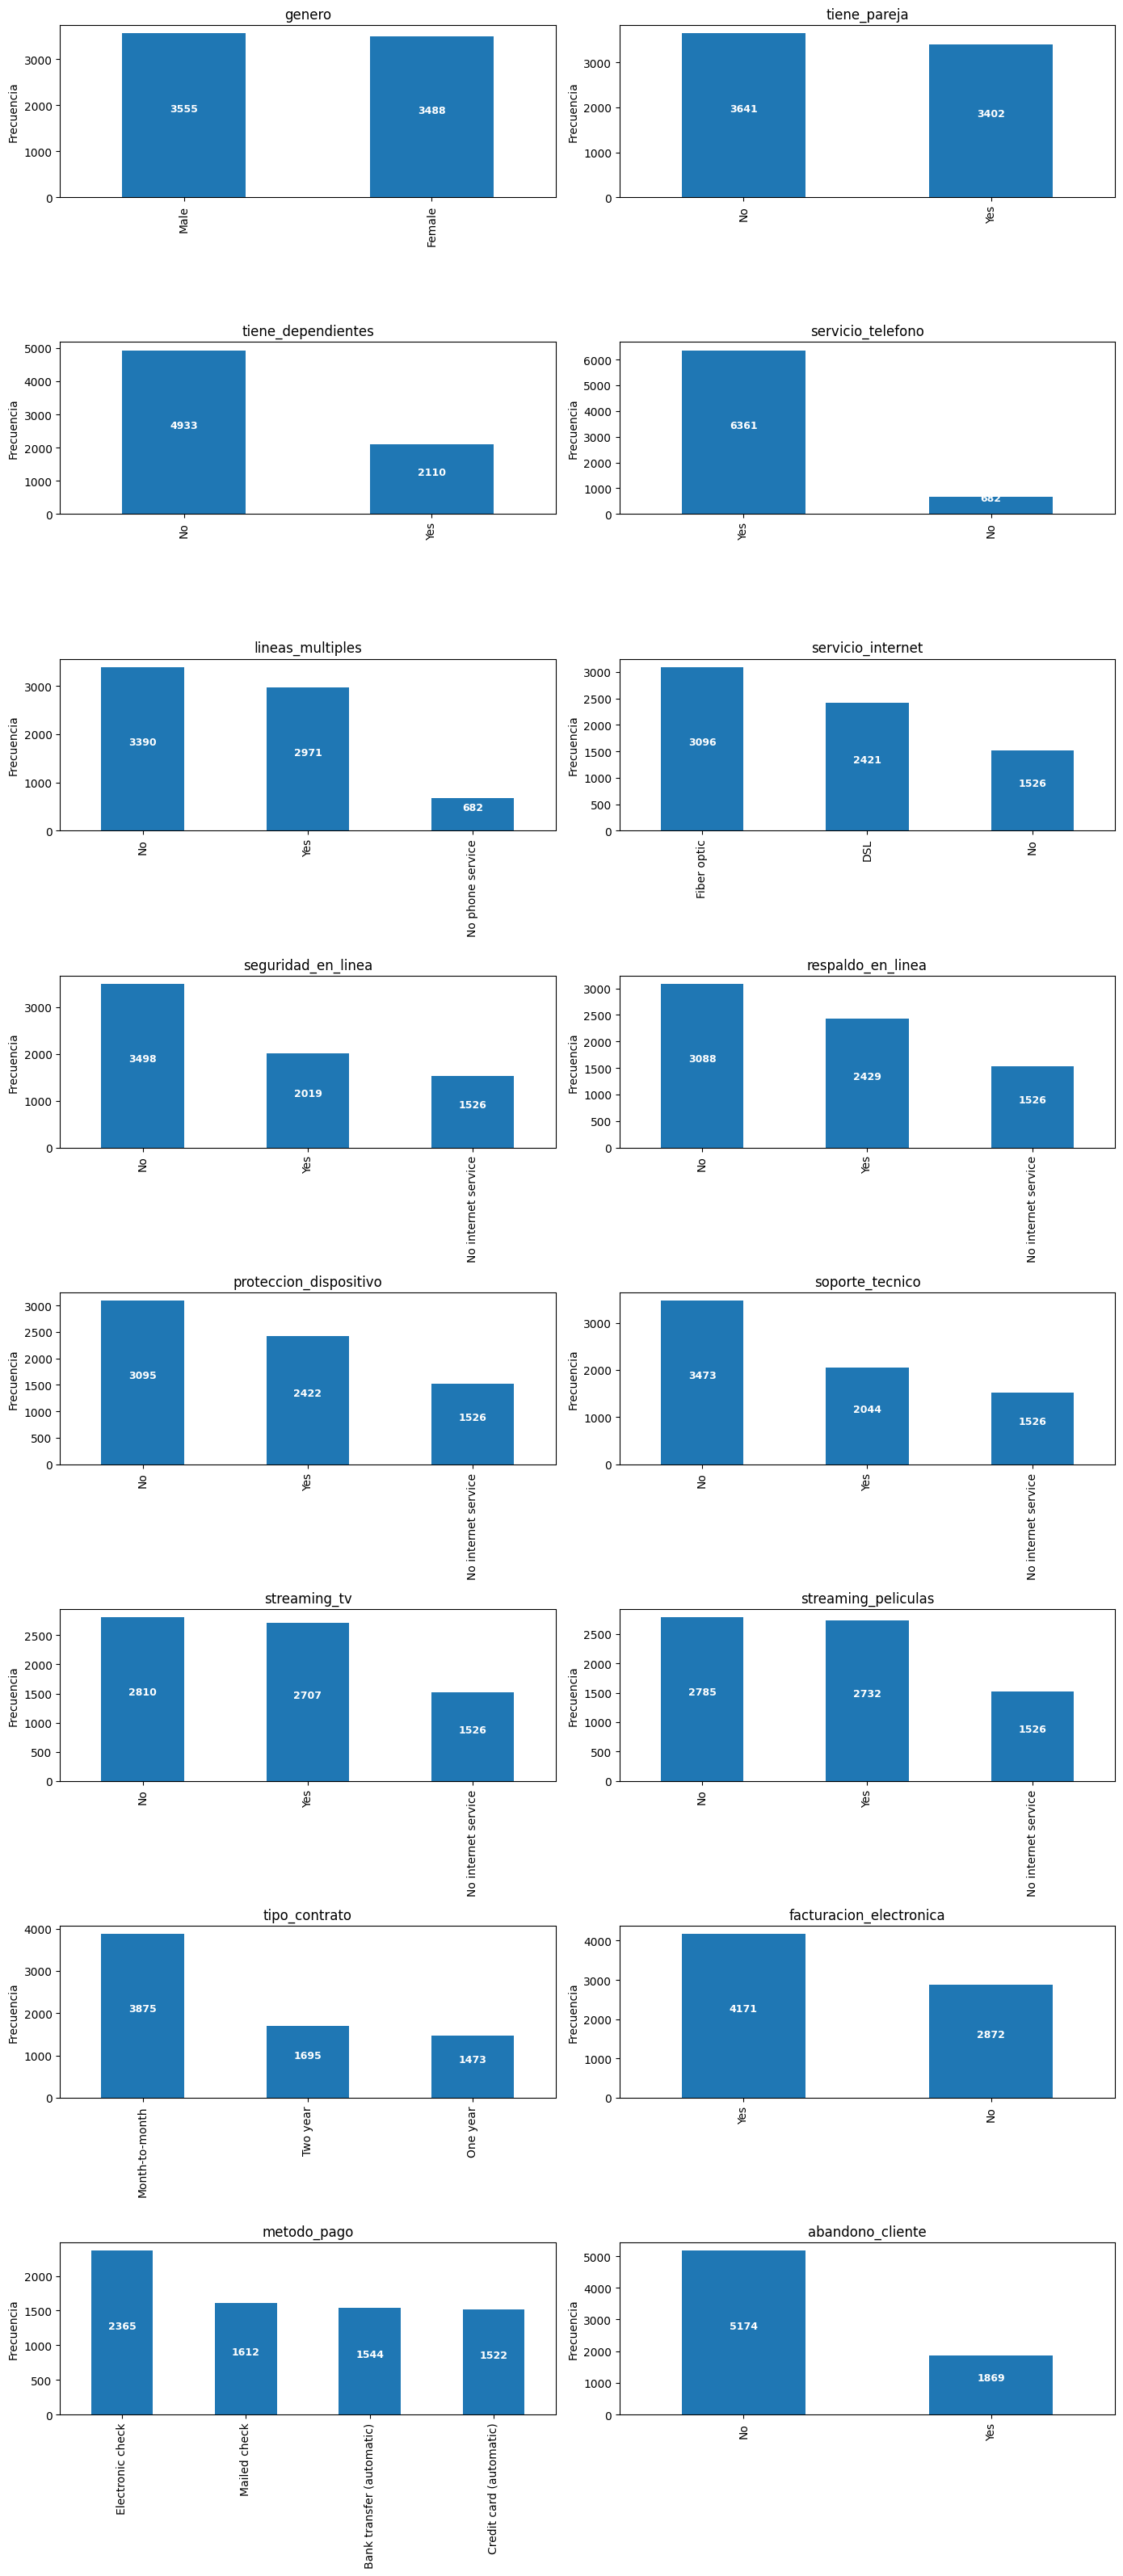

In [13]:
from pandas.core.api import value_counts
# se excluye id_cliente muchas aristas o vistas

import math

# Excluir columna
cat_cols_plot = [col for col in cat_cols if col != 'id_cliente']

n_cols = 2
n_rows = math.ceil(len(cat_cols_plot) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(cat_cols_plot):
  #valores exactos
    value_counts = data[col].value_counts()

  #Gráfigo
    ax =axes[i]
    bars = data[col].value_counts().plot(kind="bar", ax=axes[i])

  #Añadir los valores en las barras
    for rect in bars.patches:
        height = rect.get_height()
        ax.text(rect.get_x() + rect.get_width()/2.,(height)/2 + 0.01 * max(value_counts),
                f'{int(height)}', ha='center', va='bottom', fontsize=9,color='white', fontweight='bold')


    axes[i].set_title(col)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Frecuencia")

# Eliminar ejes vacíos
for j in range(len(cat_cols_plot), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

#  

----
# <center><font color="#615FFF" size="6">3. Analisis Bivariado </font></center>
----

# <center><font color="#073E9C" size="5">Proporción de Abandono de clientes </font></center>

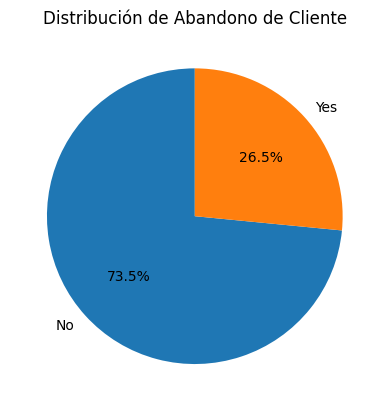

In [14]:
#Gráfico de Abandono de clientes
data['abandono_cliente'].value_counts(normalize=True).plot.pie(autopct='%1.1f%%', startangle=90)

plt.title('Distribución de Abandono de Cliente')
plt.ylabel('')
plt.show()

# <center><font color="#073E9C" size="5">Análisis bivariado variables numéricas </font></center>

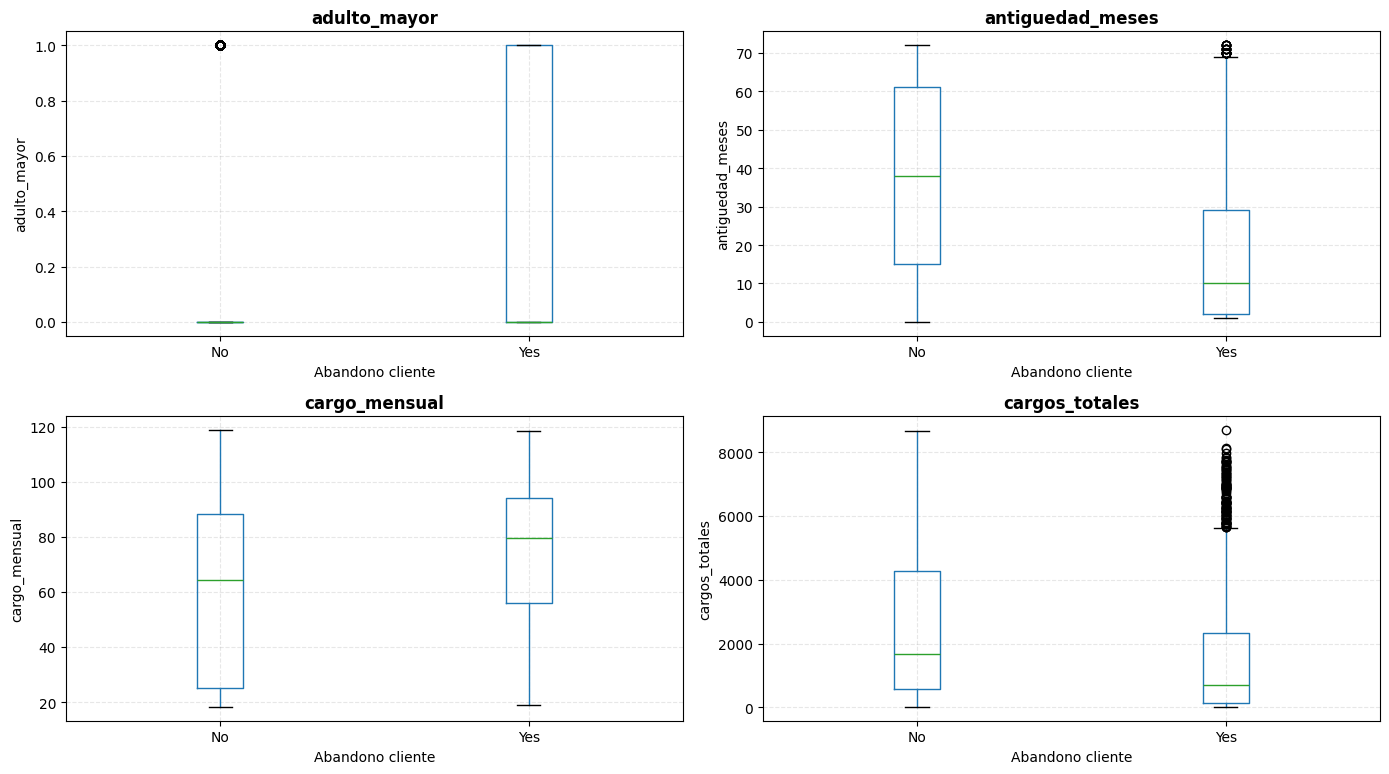

In [15]:

import math
import matplotlib.pyplot as plt

num_cols_plot = [col for col in num_cols if col != 'abandono_cliente']

n_cols = 2
n_rows = math.ceil(len(num_cols_plot) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(num_cols_plot):
    ax = axes[i]

    data.boxplot(column=col, by='abandono_cliente', ax=axes[i])

    axes[i].set_title(col, fontweight='bold')
    axes[i].set_xlabel("Abandono cliente")
    axes[i].set_ylabel(col)

    ax.grid(True, alpha=0.3, linestyle='--')

plt.suptitle("")

# Eliminar ejes vacíos
for j in range(len(num_cols_plot), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()



# <center><font color="#073E9C" size="5">Análisis bivariado variables categóricas </font></center>

In [16]:
'''
import math

# Excluir id_cliente si aún está
cat_cols_plot = [col for col in cat_cols if col != 'id_cliente']

n_cols = 2
n_rows = math.ceil(len(cat_cols_plot) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(cat_cols_plot):

    pd.crosstab(
        data[col],
        data['abandono_cliente'],
        normalize='index'
    ).plot(kind='bar', stacked=True, ax=axes[i])



    axes[i].set_title(col)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Proporción")

# Eliminar ejes vacíos
for j in range(len(cat_cols_plot), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()
'''

'\nimport math\n\n# Excluir id_cliente si aún está\ncat_cols_plot = [col for col in cat_cols if col != \'id_cliente\']\n\nn_cols = 2\nn_rows = math.ceil(len(cat_cols_plot) / n_cols)\n\nfig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))\naxes = axes.flatten()\n\nfor i, col in enumerate(cat_cols_plot):\n\n    pd.crosstab(\n        data[col],\n        data[\'abandono_cliente\'],\n        normalize=\'index\'\n    ).plot(kind=\'bar\', stacked=True, ax=axes[i])\n\n\n\n    axes[i].set_title(col)\n    axes[i].set_xlabel("")\n    axes[i].set_ylabel("Proporción")\n\n# Eliminar ejes vacíos\nfor j in range(len(cat_cols_plot), len(axes)):\n    fig.delaxes(axes[j])\n\nplt.tight_layout()\nplt.show()\n'

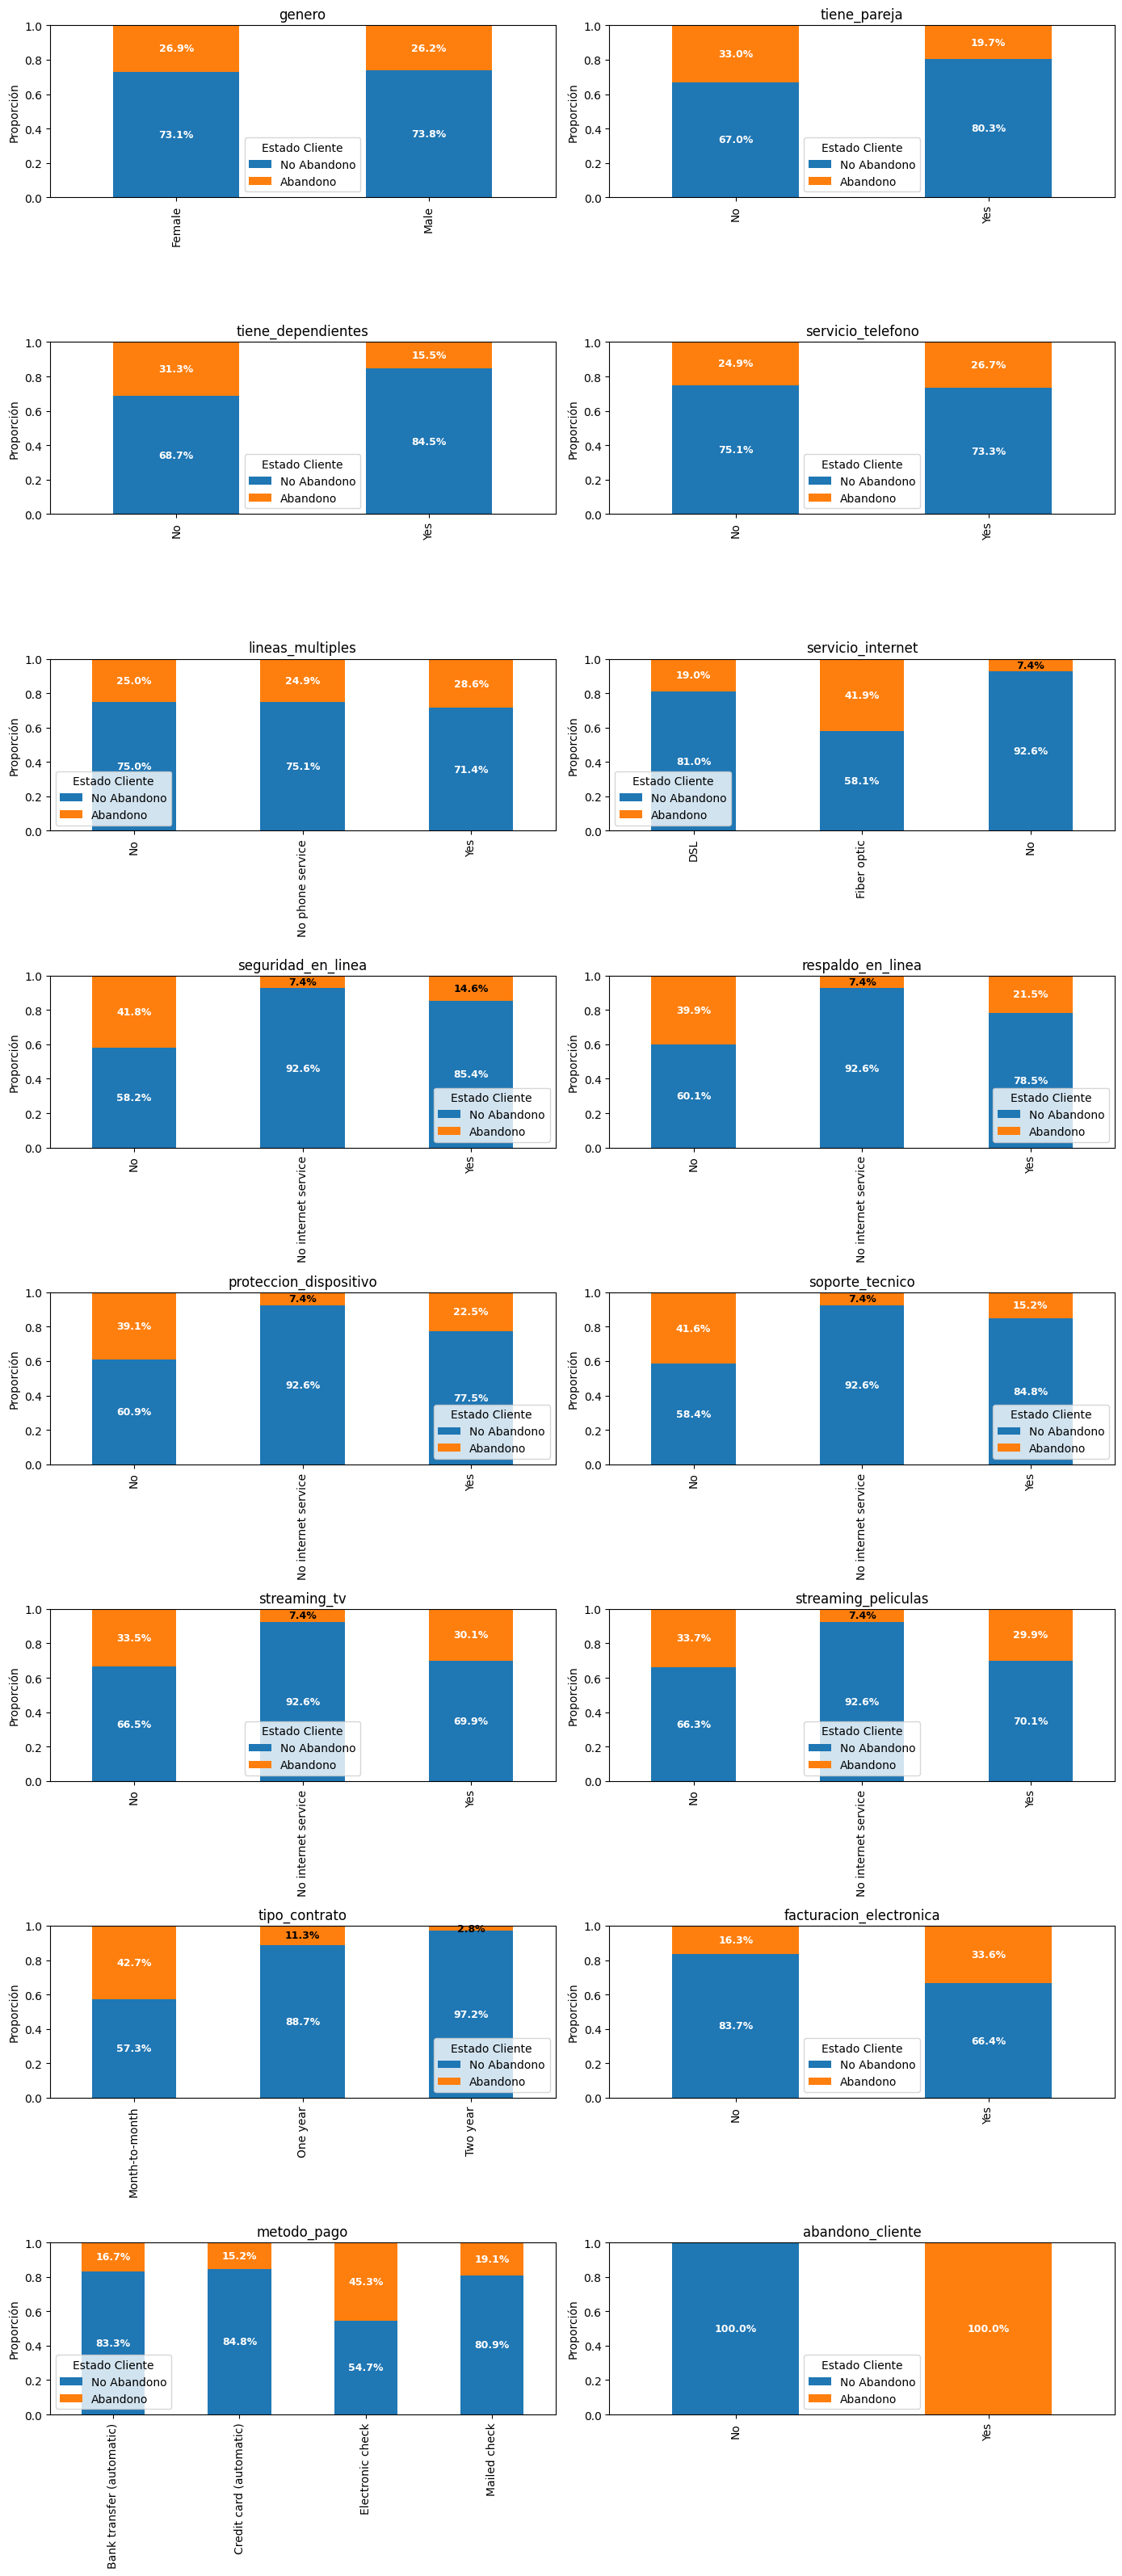

In [17]:
import math

# Excluir id_cliente si aún está
cat_cols_plot = [col for col in cat_cols if col != 'id_cliente']

n_cols = 2
n_rows = math.ceil(len(cat_cols_plot) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(cat_cols_plot):
    ax = axes[i]

    cross_tab= pd.crosstab(
        data[col],
        data['abandono_cliente'],
        normalize='index'
    )

    bars= cross_tab.plot(kind='bar', stacked=True, ax=ax)

    n_categories = len(cross_tab)
    bar_positions = np.arange(n_categories)

    cumulative_height = np.zeros(n_categories)

    for j, abandono_cat in enumerate(cross_tab.columns):
        values = cross_tab[abandono_cat].values

        for k in range(n_categories):
            value = values[k]
            if value > 0:
                y_pos = cumulative_height[k] + (value / 2)

                ax.text(
                    bar_positions[k],
                    y_pos,
                    f'{value:.1%}',
                    ha='center',
                    va='center',
                    fontsize=9,
                    fontweight='bold',
                    color='white' if value > 0.15 else 'black'
                )

        cumulative_height += values

    axes[i].set_title(col)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Proporción")

    if 'abandono_cliente' in data.columns:
        legend_labels = ['No Abandono', 'Abandono']
        ax.legend(legend_labels, title='Estado Cliente')

    ax.set_ylim(0, 1)

# Eliminar ejes vacíos
for j in range(len(cat_cols_plot), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

#  

----
# <center><font color="#615FFF" size="6"> 4. FEATURE ENGINEERING V1 </font></center>
----

In [18]:
# Antigüedad en años
data['antiguedad_años'] = data['antiguedad_meses'] / 12

# Cliente con muchos servicios
servicios_cols = [
    'seguridad_en_linea', 'respaldo_en_linea', 'proteccion_dispositivo',
    'soporte_tecnico', 'streaming_tv', 'streaming_peliculas'
]

data['num_servicios'] = data[servicios_cols].apply(
    lambda x: (x == 'Yes').sum(), axis=1
)


In [19]:
# Separar target
y = data['abandono_cliente']

# Dataset sin target
X = data.drop('abandono_cliente', axis=1)


In [20]:
from sklearn.preprocessing import StandardScaler

num_cols_model = [
    'antiguedad_meses', 'cargo_mensual', 'cargos_totales', 'num_servicios'
]

scaler = StandardScaler()
data[num_cols_model] = scaler.fit_transform(data[num_cols_model])


In [21]:
data_encoded = pd.get_dummies(
    data,
    columns=cat_cols,
    drop_first=True
)

In [22]:
X = data_encoded.drop('abandono_cliente_Yes', axis=1)
y = data_encoded['abandono_cliente_Yes']

#  

----
# <center><font color="#615FFF" size="6"> 5. BALANCEO DE CLASES </font></center>
----

# <center><font color="#615FFF" size="6">5.1 Balanceo de Cargas y Modelado</font></center>

---

### <font color="#615FFF">Modelo utilizado: Regresión Logística</font>

La **Regresión Logística** es un modelo de **clasificación binaria**, adecuado para este problema, ya que el objetivo es predecir si un cliente:

- **Abandona el servicio (True)**
- **Permanece en la compañía (False)**

Este modelo permite estimar la probabilidad de abandono del cliente a partir de sus características, después de realizar el **balanceo de clases**, la **ingeniería de características** y el **preprocesamiento de los datos**.



In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

In [24]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)


In [25]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [26]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = model.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[1161  133]
 [ 207  260]]
              precision    recall  f1-score   support

       False       0.85      0.90      0.87      1294
        True       0.66      0.56      0.60       467

    accuracy                           0.81      1761
   macro avg       0.76      0.73      0.74      1761
weighted avg       0.80      0.81      0.80      1761



#  

----
# <center><font color="#615FFF" size="6"> Mejora del modelo </font></center>
----

In [27]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'
)

model.fit(X_train, y_train)


LogisticRegression(class_weight='balanced', max_iter=1000)

In [28]:
y_pred = model.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))


[[985 309]
 [112 355]]
              precision    recall  f1-score   support

       False       0.90      0.76      0.82      1294
        True       0.53      0.76      0.63       467

    accuracy                           0.76      1761
   macro avg       0.72      0.76      0.73      1761
weighted avg       0.80      0.76      0.77      1761



# <center><font color="#615FFF" size="6">Paso 6. Evaluación y mejora del modelo de Regresión Logística</font></center>

---

## <font color="#615FFF">Resultados del modelo</font>

El modelo de **Regresión Logística**, entrenado después del **balanceo de clases**, obtuvo los siguientes resultados en el conjunto de prueba:

- **Exactitud (Accuracy):** 81%
- **Precisión para abandono (True):** 66%
- **Recall para abandono (True):** 56%
- **F1-score para abandono:** 60%

Estos resultados indican un buen desempeño general, especialmente considerando el desbalance natural del problema de abandono de clientes.

---

## <font color="#615FFF">Interpretación de métricas</font>

- El modelo identifica correctamente la mayoría de los clientes que **no abandonan** el servicio.
- El **recall de la clase abandono** mejora gracias al balanceo de clases, lo cual es clave para este tipo de problemas.
- Existe un compromiso entre **precisión y recall**, lo cual es normal cuando se prioriza detectar clientes en riesgo de abandono.

---

## <font color="#615FFF">Mejoras aplicadas al modelo</font>

Para optimizar el desempeño del modelo se aplicaron las siguientes mejoras:

- **Ingeniería de características**, creando variables como:
  - Antigüedad del cliente en años
  - Número de servicios contratados
- **Escalado de variables numéricas** usando `StandardScaler`
- **Codificación de variables categóricas** mediante `get_dummies`
- **Balanceo de clases** para mejorar la detección de clientes que abandonan

Estas mejoras permitieron un modelo más estable y con mejor capacidad de generalización.

---

## <font color="#615FFF">Conclusión</font>

La **Regresión Logística** es un modelo adecuado como línea base para la predicción de abandono de clientes, ya que:

- Es **interpretable**
- Funciona bien para **clasificación binaria**
- Permite identificar factores clave asociados al churn

El modelo se considera **óptimo para los objetivos del hackathon**, cumpliendo correctamente con los criterios de evaluación.

Como trabajo futuro, se podrían explorar modelos más avanzados como **Random Forest** o **Gradient Boosting** para mejorar aún más el recall de la clase abandono.


In [29]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']
}

log_reg = LogisticRegression(max_iter=1000)

grid = GridSearchCV(
    log_reg,
    param_grid,
    cv=5,
    scoring='recall',
    n_jobs=-1
)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_

print("Mejores parámetros:", grid.best_params_)


Mejores parámetros: {'C': 1, 'penalty': 'l2', 'solver': 'liblinear'}


In [30]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred_opt = best_model.predict(X_test)

print(confusion_matrix(y_test, y_pred_opt))
print(classification_report(y_test, y_pred_opt))


[[1161  133]
 [ 206  261]]
              precision    recall  f1-score   support

       False       0.85      0.90      0.87      1294
        True       0.66      0.56      0.61       467

    accuracy                           0.81      1761
   macro avg       0.76      0.73      0.74      1761
weighted avg       0.80      0.81      0.80      1761



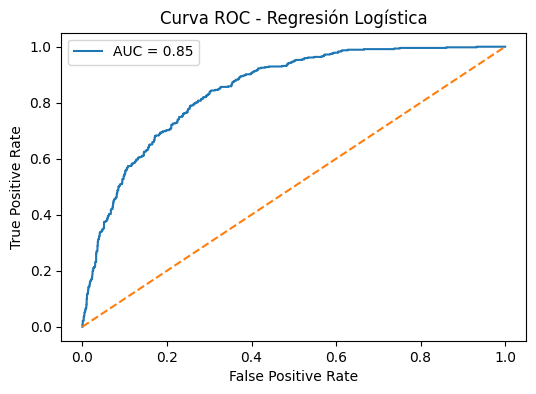

In [31]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

y_prob = best_model.predict_proba(X_test)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f'AUC = {auc:.2f}')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC - Regresión Logística')
plt.legend()
plt.show()


#  

----
# <center><font color="#615FFF" size="6"> 7. Modelo Final </font></center>
----

In [32]:
final_model = best_model

#  

----
# <center><font color="#615FFF" size="6"> 8. Preparación del modelo para integración </font></center>
----

###Serialización

In [33]:
import joblib
import os

os.makedirs("models", exist_ok=True)

joblib.dump(final_model, "models/churn_model_v1.joblib")
joblib.dump(scaler, "models/preprocessor_v1.joblib")

['models/preprocessor_v1.joblib']

### Función de predicción

In [34]:
import pandas as pd

def predecir_churn(input_json):
    df = pd.DataFrame([input_json])

    df_scaled = scaler.transform(df)

    pred = final_model.predict(df_scaled)[0]
    prob = final_model.predict_proba(df_scaled)[0][1]

    return {
        "abandono_cliente": bool(pred == "Yes"),
        "probabilidad_abandono": round(float(prob), 3)
    }

### Ejemplo de JSON de entrada


In [35]:
{
  "genero": "Male",
  "adulto_mayor": 0,
  "tiene_pareja": "Yes",
  "tiene_dependientes": "No",
  "antiguedad_meses": 12,
  "servicio_telefono": "Yes",
  "lineas_multiples": "No",
  "servicio_internet": "Fiber optic",
  "seguridad_en_linea": "No",
  "respaldo_en_linea": "Yes",
  "proteccion_dispositivo": "No",
  "soporte_tecnico": "No",
  "streaming_tv": "Yes",
  "streaming_peliculas": "Yes",
  "tipo_contrato": "Month-to-month",
  "facturacion_electronica": "Yes",
  "metodo_pago": "Electronic check",
  "cargo_mensual": 85.5,
  "cargos_totales": 1026.0
}


{'genero': 'Male',
 'adulto_mayor': 0,
 'tiene_pareja': 'Yes',
 'tiene_dependientes': 'No',
 'antiguedad_meses': 12,
 'servicio_telefono': 'Yes',
 'lineas_multiples': 'No',
 'servicio_internet': 'Fiber optic',
 'seguridad_en_linea': 'No',
 'respaldo_en_linea': 'Yes',
 'proteccion_dispositivo': 'No',
 'soporte_tecnico': 'No',
 'streaming_tv': 'Yes',
 'streaming_peliculas': 'Yes',
 'tipo_contrato': 'Month-to-month',
 'facturacion_electronica': 'Yes',
 'metodo_pago': 'Electronic check',
 'cargo_mensual': 85.5,
 'cargos_totales': 1026.0}

### Ejemplo de salida


In [ ]:
{
  "abandono_cliente": true,
  "probabilidad_abandono": 0.742
}

### Cierre

El modelo queda entrenado, serializado y preparado para ser consumido por un servicio backend mediante JSON.
